In [1]:
#  OPTIMIZER COMPARISON
# ============================================

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import (
    SGD,
    RMSprop,
    Adam
)

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:

# 1. Create Dataset
# --------------------------------------------

X, y = make_moons(
    n_samples=1000,
    noise=0.2,
    random_state=42
)

# --------------------------------------------
# 2. Train/Test Split
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------------------
# 3. Feature Scaling
# --------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# --------------------------------------------
# 4. Function to Create Model
# --------------------------------------------

def create_model(optimizer):

    model = Sequential([
        Dense(16, activation="relu", input_shape=(2,)),
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# --------------------------------------------
# 5. Define Optimizers
# --------------------------------------------

optimizers = {

    "SGD": SGD(learning_rate=0.01),

    "SGD + Momentum": SGD(
        learning_rate=0.01,
        momentum=0.9
    ),

    "RMSprop": RMSprop(
        learning_rate=0.001
    ),

    "Adam": Adam(
        learning_rate=0.001
    )
}


# --------------------------------------------
# 6. Train Models
# --------------------------------------------

histories = {}

for name, optimizer in optimizers.items():

    print("\nTraining:", name)

    model = create_model(optimizer)

    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    histories[name] = history


# --------------------------------------------



Training: SGD


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training: SGD + Momentum

Training: RMSprop

Training: Adam


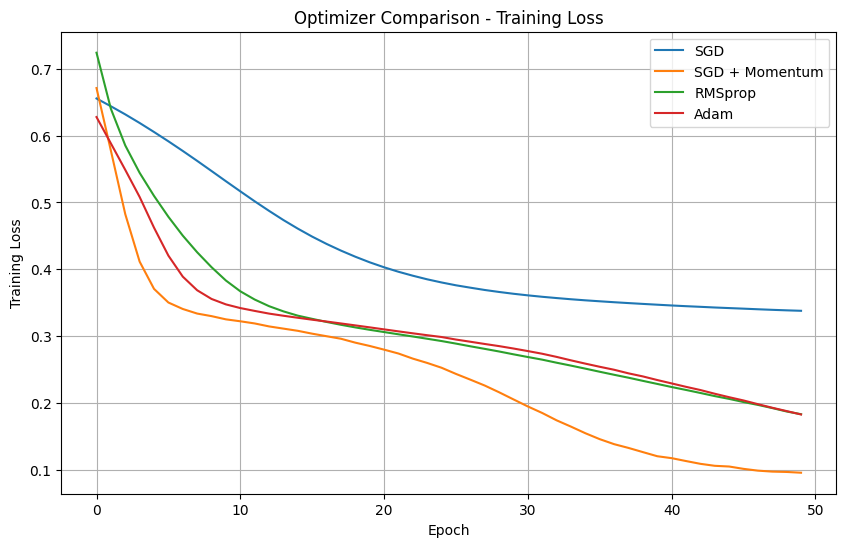

In [3]:
# 7. Compare Training Loss
# --------------------------------------------

plt.figure(figsize=(10, 6))

for name, history in histories.items():

    plt.plot(
        history.history["loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Optimizer Comparison - Training Loss")

plt.legend()
plt.grid()

plt.show()


# --------------------------------------------


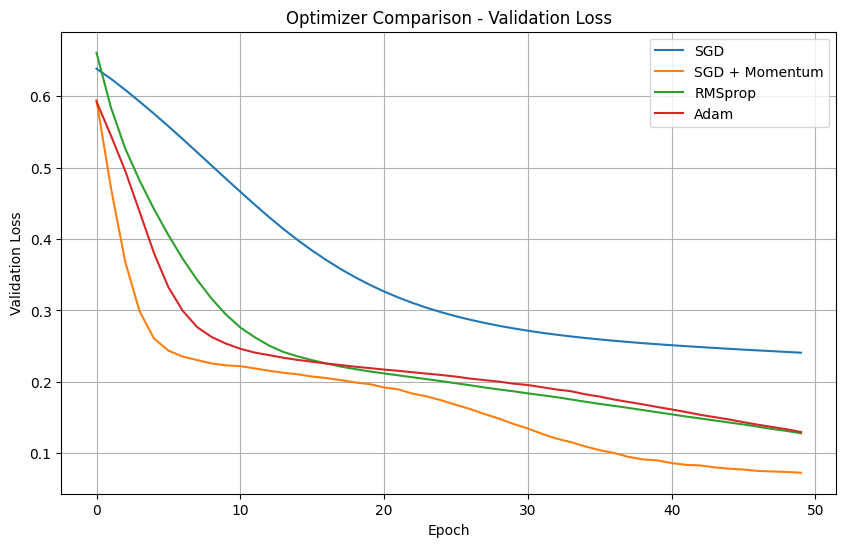

In [4]:
# 8. Compare Validation Loss
# --------------------------------------------

plt.figure(figsize=(10, 6))

for name, history in histories.items():

    plt.plot(
        history.history["val_loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Optimizer Comparison - Validation Loss")

plt.legend()
plt.grid()

plt.show()


# --------------------------------------------


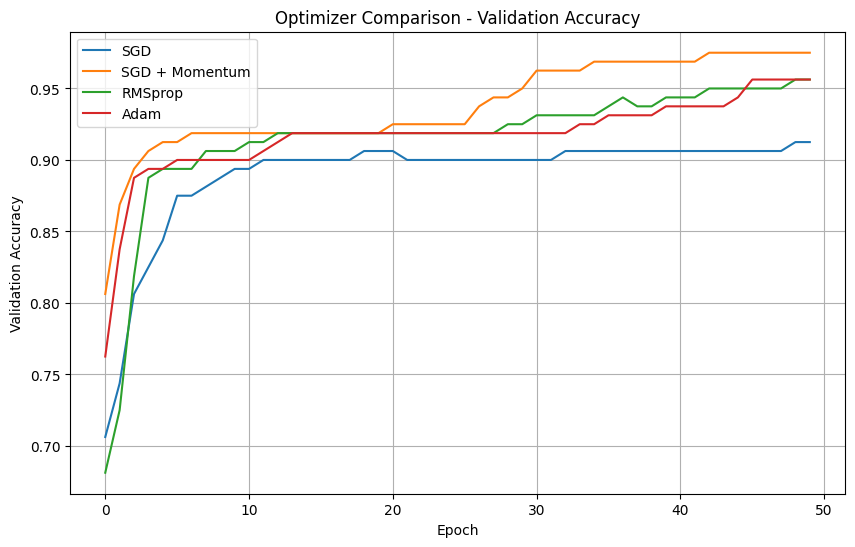

In [5]:
# 9. Compare Validation Accuracy
# --------------------------------------------

plt.figure(figsize=(10, 6))

for name, history in histories.items():

    plt.plot(
        history.history["val_accuracy"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Optimizer Comparison - Validation Accuracy")

plt.legend()
plt.grid()

plt.show()


# --------------------------------------------


In [6]:
# 10. Final Results
# --------------------------------------------

print("\nFinal Optimizer Results")
print("=" * 50)

for name, history in histories.items():

    final_loss = history.history["val_loss"][-1]
    final_accuracy = history.history["val_accuracy"][-1]

    print(f"\n{name}")
    print("Validation Loss:", final_loss)
    print("Validation Accuracy:", final_accuracy)


Final Optimizer Results

SGD
Validation Loss: 0.24091777205467224
Validation Accuracy: 0.9125000238418579

SGD + Momentum
Validation Loss: 0.072866290807724
Validation Accuracy: 0.9750000238418579

RMSprop
Validation Loss: 0.12812569737434387
Validation Accuracy: 0.956250011920929

Adam
Validation Loss: 0.1298462599515915
Validation Accuracy: 0.956250011920929
